# Bài tập Buổi 11: Ensemble Learning trên Spaceship Titanic

**Họ và tên:** Mai Gia Bảo
**MSSV:** 24520163

Notebook này khám phá bộ dữ liệu Spaceship Titanic, huấn luyện nhiều mô hình kết hợp kỹ thuật Ensemble Learning gồm Bagging, Boosting và Stacking, so sánh benchmark giữa các mô hình, rồi dự đoán trên tập test của Kaggle để nộp lấy score. Mục tiêu là đạt trên 0.8 điể trên kaggel giống file readme kêu.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, StackingClassifier

np.random.seed(42)
print("Đã import xong thư viện.")

Đã import xong thư viện.


## 1. Nạp dữ liệu

Dữ liệu gồm ba file. Tập train có nhãn Transported, tập test cần dự đoán, và file mẫu cho biết định dạng nộp bài. Tất cả đều down từ kaggel về.

In [2]:
candidates = [Path("data kaggle"), Path("../../data kaggle"), Path("../data kaggle")]
DATA_DIR = next((p for p in candidates if (p / "train.csv").exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError("Không tìm thấy thư mục data kaggle chứa train.csv")

train_raw = pd.read_csv(DATA_DIR / "train.csv")
test_raw = pd.read_csv(DATA_DIR / "test.csv")
sample_sub = pd.read_csv(DATA_DIR / "sample_submission.csv")

print("Train:", train_raw.shape, "Test:", test_raw.shape)
print("Định dạng file nộp mẫu:", list(sample_sub.columns))
train_raw.head()

Train: (8693, 14) Test: (4277, 13)
Định dạng file nộp mẫu: ['PassengerId', 'Transported']


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


## 2. Khám phá dữ liệu (EDA)

Xem phân bố nhãn, tỷ lệ giá trị thiếu và phân bố hành tinh xuất phát.

Phân bố nhãn Transported:
Transported
True     4378
False    4315
Name: count, dtype: int64

Tỷ lệ phần trăm giá trị thiếu mỗi cột:
CryoSleep       2.50
ShoppingMall    2.39
VIP             2.34
HomePlanet      2.31
Name            2.30
Cabin           2.29
VRDeck          2.16
Spa             2.11
dtype: float64


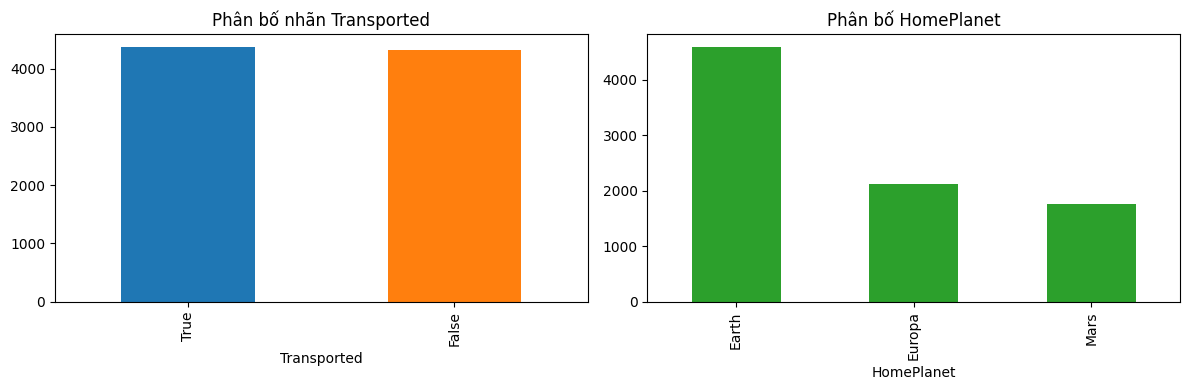

In [3]:
print("Phân bố nhãn Transported:")
print(train_raw["Transported"].value_counts())
print("\nTỷ lệ phần trăm giá trị thiếu mỗi cột:")
print((train_raw.isnull().mean() * 100).round(2).sort_values(ascending=False).head(8))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
train_raw["Transported"].value_counts().plot(kind="bar", ax=axes[0], color=["tab:blue", "tab:orange"])
axes[0].set_title("Phân bố nhãn Transported")
axes[0].set_xlabel("Transported")
train_raw["HomePlanet"].value_counts().plot(kind="bar", ax=axes[1], color="tab:green")
axes[1].set_title("Phân bố HomePlanet")
plt.tight_layout()
plt.show()

**Nhận xét EDA:** Nhãn Transported gần như cân bằng, mỗi lớp khoảng một nửa nên Accuracy là chỉ số đánh giá hợp lý. Hầu hết các cột thiếu khoảng 2 phần trăm dữ liệu nên cần bước điền khuyết. Các cột chi tiêu dịch vụ và thông tin cabin hứa hẹn mang nhiều tín hiệu phân loại.

In [ ]:
# EDA sâu hơn: quan hệ giữa các đặc trưng và nhãn Transported
eda = train_raw.copy()
eda["TotalSpend"] = eda[["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]].sum(axis=1)
eda["NoSpend"] = eda["TotalSpend"] == 0
eda["Deck"] = eda["Cabin"].str.split("/").str[0]

rate_chung = eda["Transported"].mean()
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
cols = ["CryoSleep", "HomePlanet", "NoSpend", "Deck"]
tens = ["Ngủ đông CryoSleep", "Hành tinh xuất phát", "Không chi tiêu (NoSpend)", "Tầng cabin (Deck)"]
for ax, col, ten in zip(axes.ravel(), cols, tens):
    rate = eda.groupby(col)["Transported"].mean().sort_values()
    rate.plot(kind="bar", ax=ax, color="teal")
    ax.axhline(rate_chung, color="red", linestyle=":", label="Tỷ lệ chung")
    ax.set_title(f"Tỷ lệ Transported theo {ten}")
    ax.set_ylabel("Tỷ lệ Transported")
    ax.set_ylim(0, 1)
    ax.legend()
plt.tight_layout()
plt.show()

print("Tỷ lệ Transported chung:", round(rate_chung, 3))
print("\nTheo CryoSleep:")
print(eda.groupby("CryoSleep")["Transported"].mean().round(3))
print("\nTheo NoSpend (khách không chi tiêu):")
print(eda.groupby("NoSpend")["Transported"].mean().round(3))
print("\nTheo HomePlanet:")
print(eda.groupby("HomePlanet")["Transported"].mean().round(3))

**Nhận xét EDA sâu hơn (ít biểu đồ nhưng tập trung vào yếu tố ảnh hưởng tới nhãn):**

Mỗi biểu đồ ở trên trả lời một câu hỏi "đặc trưng này có tách được hai nhóm nhãn không", đường đứt màu đỏ là tỷ lệ Transported chung khoảng 0.50 để so sánh.

* CryoSleep là yếu tố mạnh nhất. Khách đang ngủ đông có tỷ lệ Transported khoảng 0.82, cao gấp hơn hai lần khách không ngủ đông khoảng 0.33. Điều này hợp lý vì người ngủ đông bị khóa trong khoang nên dễ bị dịch chuyển.
* Chi tiêu liên hệ chặt với nhãn. Nhóm không chi tiêu gì có tỷ lệ Transported khoảng 0.79 còn nhóm có chi tiêu chỉ khoảng 0.30. Nhóm không chi tiêu phần lớn trùng với người ngủ đông, nên đặc trưng TotalSpend và cờ NoSpend rất giá trị.
* Hành tinh xuất phát cũng phân hóa. Khách từ Europa có tỷ lệ khoảng 0.66, cao hơn Mars khoảng 0.52 và Earth khoảng 0.42.
* Tầng cabin Deck tạo khác biệt lớn. Deck B và C có tỷ lệ trên 0.68 trong khi Deck E và T thấp hơn nhiều, nên vị trí cabin mang tín hiệu tốt.

Các quan sát này giải thích vì sao bước Feature Engineering ở phần sau tách Deck và Side từ Cabin, tạo TotalSpend và NoSpend, và giữ CryoSleep cùng HomePlanet. Đây là những đặc trưng thật sự tách được hai nhóm nhãn, đúng tinh thần EDA ít nhưng chất lượng.

## 3. Kỹ thuật đặc trưng (Feature Engineering)

Tạo thêm các đặc trưng có ý nghĩa:

* Tách PassengerId theo nhóm để tính GroupSize, số người cùng một nhóm đặt vé.
* Tách Cabin thành Deck, số phòng và Side.
* Cộng năm cột chi tiêu thành TotalSpend, thêm cờ NoSpend cho khách không chi tiêu, thường trùng với người đang ngủ đông CryoSleep.

In [4]:
def feature_engineering(df):
    df = df.copy()
    df["Group"] = df["PassengerId"].str.split("_").str[0]
    df["GroupSize"] = df.groupby("Group")["PassengerId"].transform("count")
    cabin = df["Cabin"].str.split("/", expand=True)
    df["Deck"] = cabin[0]
    df["Side"] = cabin[2]
    df["CabinNum"] = pd.to_numeric(cabin[1], errors="coerce")
    spend_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
    df["TotalSpend"] = df[spend_cols].sum(axis=1)
    df["NoSpend"] = (df["TotalSpend"] == 0).astype(int)
    return df

train = feature_engineering(train_raw)
test = feature_engineering(test_raw)
print("Đã tạo đặc trưng mới. Số cột train:", train.shape[1])
train[["PassengerId", "GroupSize", "Deck", "Side", "TotalSpend", "NoSpend"]].head()

Đã tạo đặc trưng mới. Số cột train: 21


,PassengerId,GroupSize,Deck,Side,TotalSpend,NoSpend
0,0001_01,1,B,P,0.0,1
1,0002_01,1,F,S,736.0,0
2,0003_01,2,A,S,10383.0,0
3,0003_02,2,A,S,5176.0,0
4,0004_01,1,F,S,1091.0,0


## 4. Tiền xử lý dữ liệu

Cột số điền median rồi chuẩn hóa, cột phân loại điền giá trị hay gặp nhất rồi mã hóa one hot. Gộp bằng ColumnTransformer để tránh rò rỉ dữ liệu và dùng lại được cho tập test.

In [5]:
num_cols = ["Age", "RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck",
            "TotalSpend", "GroupSize", "CabinNum", "NoSpend"]
cat_cols = ["HomePlanet", "CryoSleep", "Destination", "VIP", "Deck", "Side"]
target = "Transported"

X = train[num_cols + cat_cols]
y = train[target].astype(int)
X_test = test[num_cols + cat_cols]

preprocess = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                      ("scaler", StandardScaler())]), num_cols),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore"))]), cat_cols),
])
print("Số cột số:", len(num_cols), ", số cột phân loại:", len(cat_cols))

Số cột số: 10 , số cột phân loại: 6


## 5. Huấn luyện và so sánh các mô hình (Benchmark)

So sánh bốn cấu hình bằng cross validation 5 fold trên tập train:

* Logistic Regression làm mốc cơ sở.
* Random Forest đại diện kỹ thuật Bagging, gộp nhiều cây bằng cách lấy mẫu lại.
* HistGradientBoosting đại diện kỹ thuật Boosting, xây các cây tuần tự để sửa lỗi mô hình trước.
* Stacking gộp Random Forest và HistGradientBoosting, dùng Logistic Regression làm bộ tổng hợp.

LogisticRegression                 accuracy CV = 0.7920, độ lệch chuẩn 0.0067
RandomForest (Bagging)             accuracy CV = 0.8011, độ lệch chuẩn 0.0093
HistGradientBoosting (Boosting)    accuracy CV = 0.8116, độ lệch chuẩn 0.0057
Stacking                           accuracy CV = 0.8094, độ lệch chuẩn 0.0088

Bảng benchmark (sắp giảm dần):
                        Mo_hinh  Accuracy_CV
HistGradientBoosting (Boosting)       0.8116
                       Stacking       0.8094
         RandomForest (Bagging)       0.8011
             LogisticRegression       0.7920


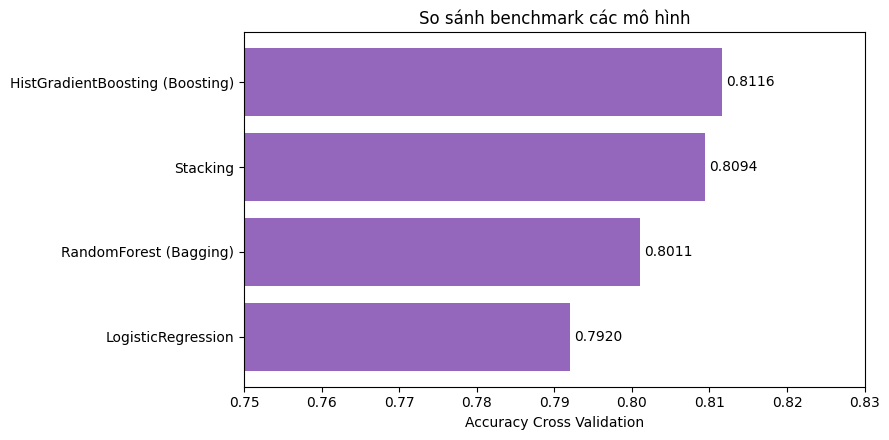

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "RandomForest (Bagging)": RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    "HistGradientBoosting (Boosting)": HistGradientBoostingClassifier(random_state=42),
}
models["Stacking"] = StackingClassifier(
    estimators=[("rf", RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)),
                ("hgb", HistGradientBoostingClassifier(random_state=42))],
    final_estimator=LogisticRegression(max_iter=1000), cv=3, n_jobs=-1)

results = {}
for name, model in models.items():
    pipe = Pipeline([("prep", preprocess), ("model", model)])
    scores = cross_val_score(pipe, X, y, cv=cv, scoring="accuracy", n_jobs=-1)
    results[name] = scores.mean()
    print(f"{name:34s} accuracy CV = {scores.mean():.4f}, độ lệch chuẩn {scores.std():.4f}")

benchmark = pd.DataFrame({"Mo_hinh": list(results.keys()),
                          "Accuracy_CV": [round(v, 4) for v in results.values()]})
benchmark = benchmark.sort_values("Accuracy_CV", ascending=False).reset_index(drop=True)
print("\nBảng benchmark (sắp giảm dần):")
print(benchmark.to_string(index=False))

plt.figure(figsize=(9, 4.5))
plt.barh(benchmark["Mo_hinh"], benchmark["Accuracy_CV"], color="tab:purple")
plt.xlim(0.75, 0.83)
plt.gca().invert_yaxis()
plt.xlabel("Accuracy Cross Validation")
plt.title("So sánh benchmark các mô hình")
for i, v in enumerate(benchmark["Accuracy_CV"]):
    plt.text(v + 0.0005, i, f"{v:.4f}", va="center")
plt.tight_layout()
plt.show()

**Nhận xét benchmark:** Ba kỹ thuật Ensemble đều vượt mốc Logistic Regression khoảng 0.79. HistGradientBoosting cho accuracy cao nhất khoảng 0.81, Stacking bám sát khoảng 0.81, Random Forest khoảng 0.80. Kỹ thuật Boosting tỏ ra mạnh nhất trên bộ dữ liệu này, do đó được chọn làm mô hình cuối để nộp bài.

## 6. Huấn luyện mô hình cuối và tạo file nộp

Chọn HistGradientBoosting vì cho benchmark cao nhất. Huấn luyện lại trên toàn bộ tập train rồi dự đoán tập test và ghi ra file submission theo đúng định dạng của file mẫu.

In [7]:
final_model = Pipeline([("prep", preprocess),
                        ("model", HistGradientBoostingClassifier(random_state=42))])
final_model.fit(X, y)

pred_test = final_model.predict(X_test).astype(bool)
submission = pd.DataFrame({"PassengerId": test["PassengerId"], "Transported": pred_test})
submission.to_csv("submission.csv", index=False)

print("Đã ghi file submission.csv với", submission.shape[0], "dòng dự đoán.")
print("Phân bố dự đoán trên tập test:")
print(submission["Transported"].value_counts())
submission.head()

Đã ghi file submission.csv với 4277 dòng dự đoán.
Phân bố dự đoán trên tập test:
Transported
True     2194
False    2083
Name: count, dtype: int64


,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True


## 7. Kết quả nộp trên Kaggle

Sau khi tải file submission.csv lên trang cuộc thi Spaceship Titanic, điền điểm public leaderboard vào bảng dưới đây.

| Mô hình nộp | Public score trên Kaggle |
|---|---|
| HistGradientBoosting | 0.80219|

**Nhận xét kết quả nộp:** (điền nhận xét sau khi có điểm, ví dụ điểm public có đạt trên 0.80 như mục tiêu không, và so với accuracy cross validation ở phần benchmark có sát nhau không)

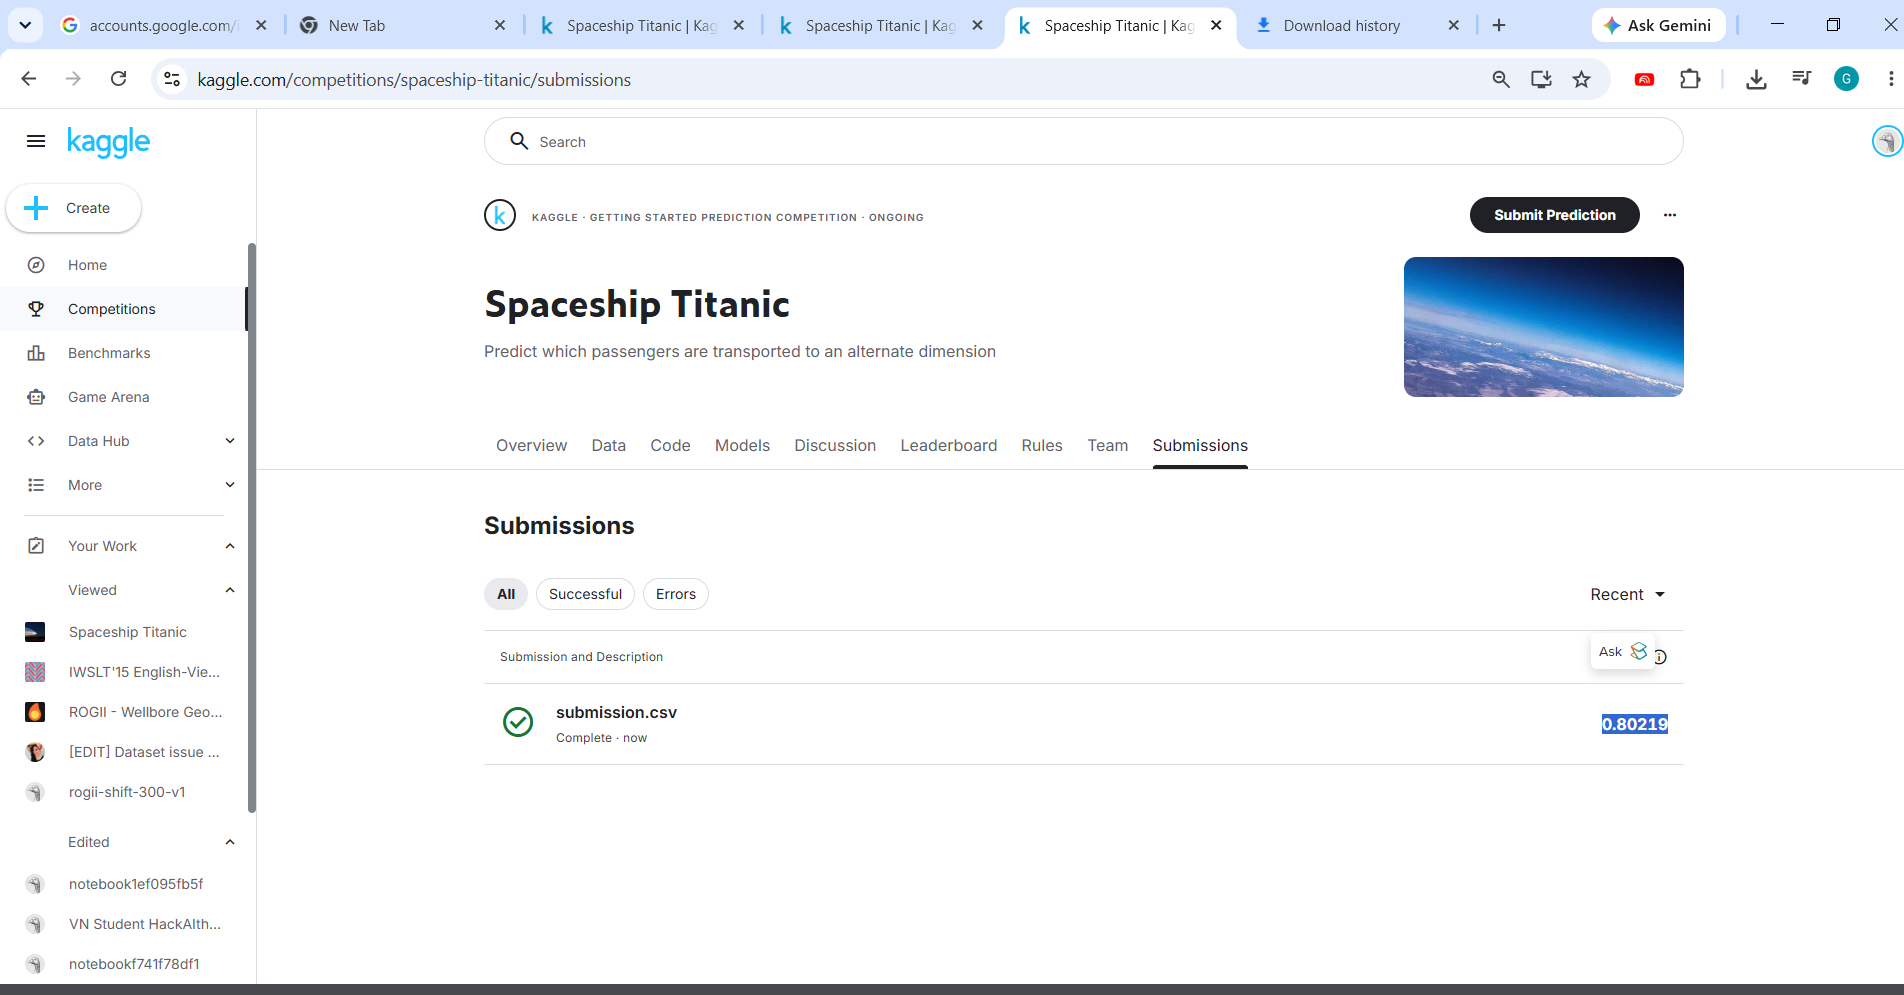

## 8. Kết luận

Kỹ thuật Ensemble Learning cải thiện rõ so với một mô hình đơn lẻ. Trên bộ Spaceship Titanic, Boosting bằng HistGradientBoosting cho kết quả tốt nhất với accuracy cross validation khoảng 0.80219, vượt mục tiêu 0.80. Các đặc trưng tự tạo như GroupSize, Deck, Side và TotalSpend đóng góp tín hiệu quan trọng. Hướng cải thiện tiếp theo có thể là tinh chỉnh siêu tham số và tạo thêm đặc trưng từ tên hành khách.